# Demonstration of iEFC with an 11 x 11 DM


In [1]:
from prysm.interferogram import (
    abc_psd,
    render_synthetic_surface
)

from prysm.coordinates import make_xy_grid, cart_to_polar
from prysm.propagation import focus_fixed_sampling
from prysm.geometry import circle
from prysm.x.dm import DM

from poi.influence_funcs import gaussian_influence_function
from poi.probes import create_sinc_probe

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import Circle
from tqdm import tqdm

# Generate Pairwise Probe Commands

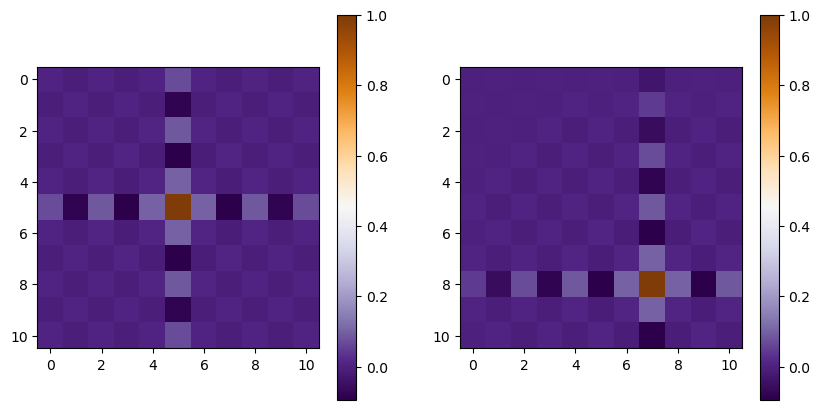

In [2]:
Nacts = 11
amp = 1
probe_radius = 5 # is this L/D ?
shift = (2, 3)

probe1 = create_sinc_probe(Nacts=Nacts,
                          amp=amp,
                          probe_radius=probe_radius)

probe2 = create_sinc_probe(Nacts=Nacts,
                          amp=amp,
                          probe_radius=probe_radius,
                          offset=shift)

plt.figure(figsize=[10, 5])
plt.subplot(121)
plt.imshow(probe1, cmap="PuOr_r")
plt.colorbar()
plt.subplot(122)
plt.imshow(probe2, cmap="PuOr_r")
plt.colorbar()
plt.show()

# Set up a PSD wavefront error

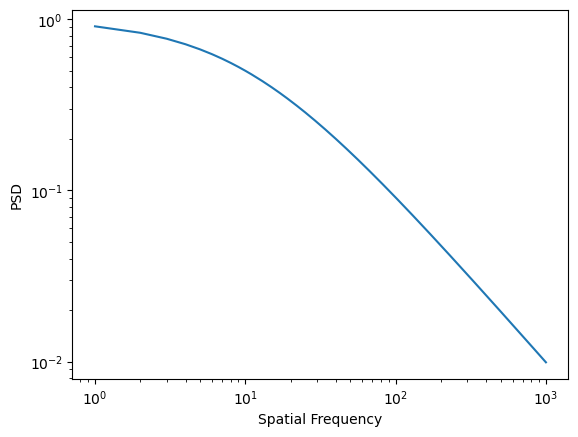

In [3]:
nu = np.arange(1,1000,1)
psd = abc_psd(nu, a=1, b=10, c=1)

plt.figure()
plt.plot(nu, psd)
plt.xscale('log')
plt.yscale('log')
plt.ylabel('PSD')
plt.xlabel('Spatial Frequency')
plt.show()


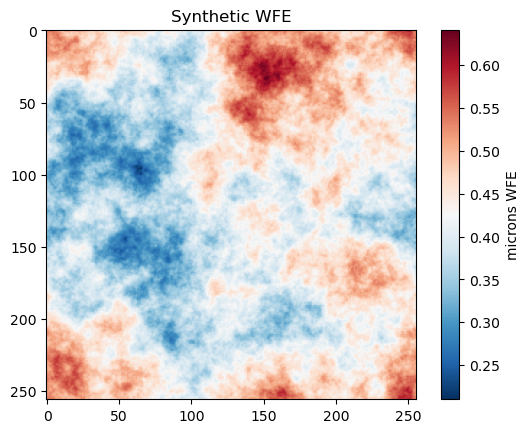

In [4]:
# Just picked ABC values until it looked about right
Npup = 256
x, y, z = render_synthetic_surface(10, Npup, a=5e4, b=1/1000, c=3)

plt.figure()
plt.title('Synthetic WFE')
plt.imshow(z, cmap='RdBu_r')
plt.colorbar(label='microns WFE')
plt.show()

# 2. Set up a diffraction model

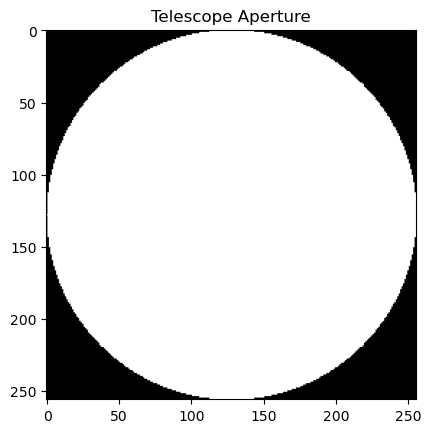

In [5]:
x, y = make_xy_grid(Npup, diameter=2)
r, t = cart_to_polar(x, y)
A = circle(1, r)
plt.figure()
plt.imshow(A, cmap='gray')
plt.title('Telescope Aperture')
plt.show()

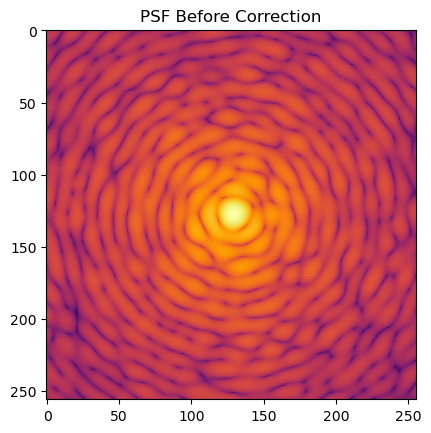

In [6]:
# create pupil function and propagate
WVL = 1 # micron
EFL = 100 # mm
Dpup = 10 # mm
dx_img = 1 # microns
wvfnt = A * np.exp(1j * 2 * np.pi / WVL * z) # with error

focal = focus_fixed_sampling(wvfnt,
                             input_dx=Dpup / wvfnt.shape[0], # mm pupil
                             prop_dist=EFL, # mm focal length
                             wavelength=WVL, # microns
                             output_dx=dx_img, # microns
                             output_samples=wvfnt.shape[0])

focal_intensity = np.abs(focal)**2

plt.title('PSF Before Correction')
plt.imshow(focal_intensity, cmap='inferno', norm=LogNorm())

# Simulate iEFC in direct imaging mode

0.1


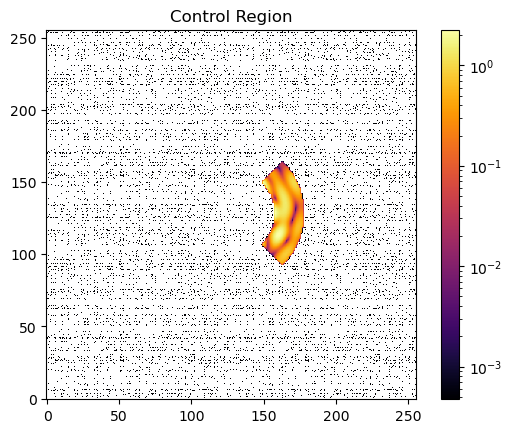

In [7]:
# create a dark hole
um_to_LD = 1e-6 / (EFL * 1e-3) * (Dpup * 1e-3) / (WVL * 1e-6)
print(um_to_LD)
u, v = make_xy_grid(focal.shape, dx=dx_img * um_to_LD)
rho, psi = cart_to_polar(u, v)

dark_hole = np.zeros_like(u)
IWA = 3
OWA = 5
dark_hole[rho < OWA] = 1
dark_hole[rho < IWA] = 0
dark_hole[psi > np.pi / 4] = 0
dark_hole[psi < -np.pi / 4] = 0
# dark_hole[u < 5] = 0


masked_intensity = dark_hole * focal_intensity
plt.title('Control Region')
plt.imshow(masked_intensity, cmap='inferno', norm=LogNorm(), origin='lower')

plt.colorbar()

# Configure Deformable Mirror with Modes

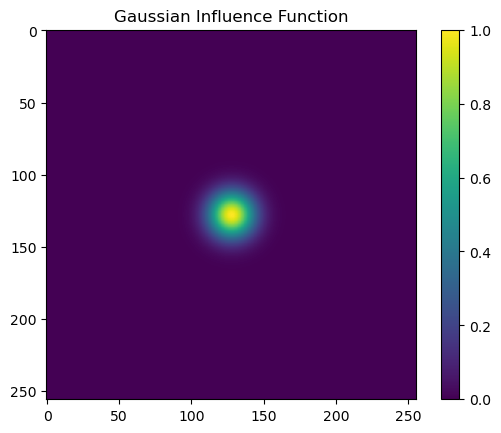

In [8]:
# Set up DM
act_pitch = 4 # mm?
samples_per_act = 21 # chosen to over-fill illuminated aperture
sampling_pitch = act_pitch / samples_per_act

xdm, ydm = make_xy_grid(Npup, dx=Dpup / Npup)
rhodm, _ = cart_to_polar(xdm, ydm)
influence_func = gaussian_influence_function(rhodm, sampling_pitch)

plt.title("Gaussian Influence Function")
plt.imshow(influence_func)
plt.colorbar()
plt.show()

In [9]:
dm = DM(influence_func,
        Nout=Npup,
        Nact=Nacts,
        sep=samples_per_act,
        shift=(samples_per_act, samples_per_act))

In [10]:
from poi.modes import poke_mode_sequence

xact, yact = make_xy_grid(Nacts, dx=act_pitch)
rhoact, thact = cart_to_polar(xact, yact)
circ_dm_mask = np.ones_like(xact)

modes = poke_mode_sequence(circ_dm_mask)

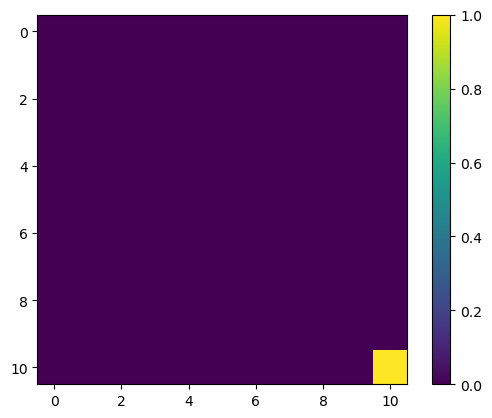

In [11]:
plt.imshow(modes[-1])
plt.colorbar()

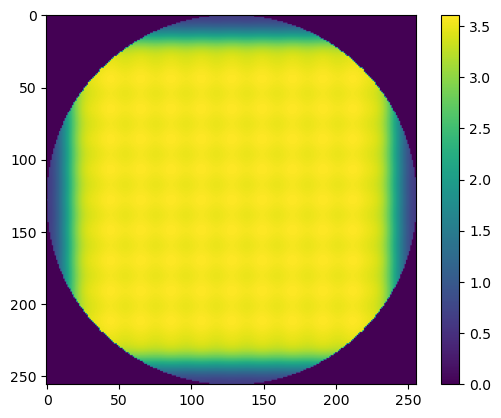

In [12]:
dm.actuators[:] = 1 # probe2 #modes[-1]
plt.imshow(dm.render() * A)
plt.colorbar()

In [13]:
def fwd(pupil_wfe=np.ones_like(wvfnt)):
    focal = focus_fixed_sampling(wvfnt * pupil_wfe * A,
                                input_dx=Dpup / wvfnt.shape[0], # mm pupil
                                prop_dist=EFL, # mm focal length
                                wavelength=WVL, # microns
                                output_dx=dx_img, # microns
                                output_samples=wvfnt.shape[0])
    return focal

In [14]:
from poi.efc import iEFC

iefc = iEFC(fwd, dm, modes, [probe1, probe2], dark_hole,
            probe_amplitude=1e-1, # radians
            mode_amplitude=1e-1)

In [15]:
iefc.calibrate()

121it [00:06, 18.60it/s]


In [16]:
iefc.compute_control_matrix()

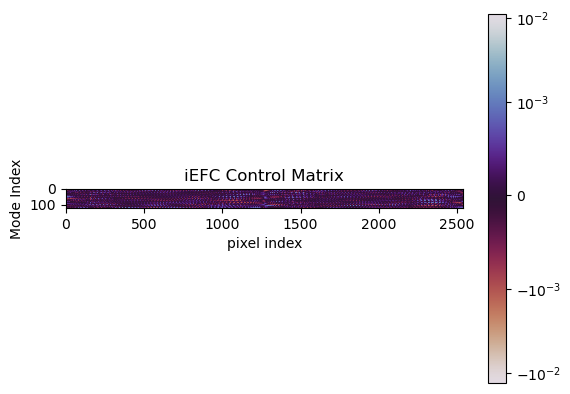

In [17]:
from matplotlib.colors import SymLogNorm
plt.title("iEFC Control Matrix")
plt.imshow(iefc.control_matrix, cmap="twilight_r", norm=SymLogNorm(linthresh=1e-3))
plt.ylabel("Mode Index")
plt.xlabel("pixel index")
plt.colorbar()

In [18]:
# try step forward
for i in range(10):
    iefc.step()

Taking starter image at position zero


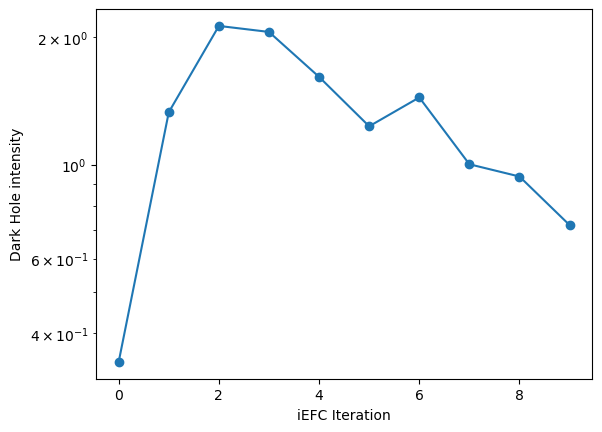

In [19]:
plt.plot(iefc.mean_in_dh, marker='o')
plt.ylabel("Dark Hole intensity")
plt.xlabel("iEFC Iteration")
plt.yscale("log")

([], [])

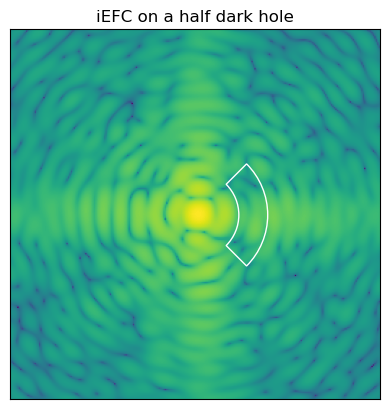

In [22]:
from matplotlib.patches import Wedge
plt.imshow(np.log10(iefc.images[1]))
plt.title("iEFC on a half dark hole")
ax = plt.gca()

# set up dark hole
scale = Dpup / dx_img / WVL
dh_region = Wedge((128, 128), r= OWA * scale, width=(OWA - IWA) * scale,
                  theta1=-45, theta2=45, facecolor="None", edgecolor="w")
ax.add_patch(dh_region)
plt.xticks([],[])
plt.yticks([],[])